In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
import gc
from scipy.stats import zscore
from scipy.signal import detrend
import copy
import sys
from scipy.integrate import simpson as simps
from nice.algorithms.connectivity import epochs_compute_wsmi
import mne
import warnings
warnings.filterwarnings("ignore")
from scipy.ndimage import gaussian_filter1d

import pyinform as pi


def smooth_with_gaussian(data, sigma=3):
    return gaussian_filter1d(data, sigma=sigma, axis=1) 

def preprocess(data):
    stds = np.std(data[:, :], axis=0)
    non_constant_cols = stds.astype(float) > 1e-6    #finds the time points where std is not 0
    const_cols = stds.astype(float) <= 1e-6    #finds the time points where std is 0

    z = np.zeros_like(data[:, :])   #creates an array of zeros with the same shape as the data
    z[:, non_constant_cols] = zscore(data[:, non_constant_cols], axis=0)  #in the columns where std is not 0, zscores the data
    z[:, const_cols] = np.mean(data[:, const_cols], axis=0)

 
    if np.isnan(z).any():
        raise ValueError("Data contains NaN values after normalization.")

    return z


file_numbers = [1, 2, 4, 8, 14, 15, 20, 23]

wsmi_means = {f'dataset_{file_number}': {'left_attleft': [], 'right_attleft': [], 'left_attright': [], 'right_attright': []} for file_number in file_numbers}
wsmi_stdevs = {f'dataset_{file_number}': {'left_attleft': [], 'right_attleft': [], 'left_attright': [], 'right_attright': []} for file_number in file_numbers}


total_time = time.time()
def collect_data(sigma = 2):
    epochs_data = {'left': [], 'right': []}
    for file_number in  file_numbers:
        file_total = time.time()
        file_path = f'C:/Users/joshu/PartIIIProject/RSNNdale_attention_{file_number}_attention_test'
        load_data_start_time = time.time()
        data = pickle.load(open(file_path, 'rb'))
        elapsed_time = time.time() - load_data_start_time
        print(f"Dataset {file_number} loaded in {elapsed_time:.2f} seconds")

        attention_labels = data['label_attend'][0]
        label_left = data['label_left'][0]
        label_right = data['label_right'][0]
        attend_01 = data['attend'][0]
        # omitted = data['omit'][0]
        # relevant = np.where(omitted ==0)[0]
        omitted = data['omit'][0]
        trial_correct = data['trial_correct'][0]
        relevant = np.where((omitted == 0) & (trial_correct == 1))[0]
    
        # left = data['SP'][0][0][relevant]
        # right = data['SP'][0][1][relevant]
        # attention_SP = data['SP'][0][2][relevant]

        # left_sm = smooth_with_gaussian(left, sigma=sigma) 
        # right_sm = smooth_with_gaussian(right, sigma=sigma) 
        # att_sm = smooth_with_gaussian(attention_SP, sigma=sigma) 

        # num_trials, num_samples, num_neurons = left.shape
        # num_neurons_attention = 80

                
        # for j in range(0, num_trials):
        #     for i in range(0, num_neurons):
        #         count_left = np.count_nonzero(left[j, :, i] == 1)
        #         if count_left > 0:
        #             left_sm[j, :, i] /= count_left
        #         count_right = np.count_nonzero(right[j, :, i] == 1)
        #         if count_right > 0:
        #             right_sm[j, :, i] /= count_right


        #     for i in range(0, num_neurons_attention):
        #         count_attention = np.count_nonzero(attention_SP[j, :, i] == 1)
        #         if count_attention > 0:
        #             att_sm[j, :, i] /= count_attention


        # left = np.sum(left_sm, axis=2)
        # right = np.sum(right_sm, axis=2)
        # attention_SP = np.sum(att_sm, axis=2)

        # left = preprocess(left)
        # right = preprocess(right)
        # attention_SP = preprocess(attention_SP)

        # #preprocess here now that we have traces of all of the relavant trials
        # left_indices_agg = np.where((omitted ==0) & (attend_01 == 0))[0]  #indices of agg where left
        # _, left_indices, _ = np.intersect1d(relevant, left_indices_agg, return_indices = True)   #indices for relevant processed data where attention left
        # right_indices_agg = np.where((omitted ==0) & (attend_01 == 1))[0]
        # _, right_indices, _ = np.intersect1d(relevant, right_indices_agg, return_indices = True)

        # #splitting left and right
        # left_attleft = left[left_indices, 100:350]
        # right_attleft = right[left_indices, 100:350]
        # attention_SP_attleft = attention_SP[left_indices, 100:350]

        # left_attright = left[right_indices, 100:350]
        # right_attright = right[right_indices, 100:350]
        # attention_SP_attright = attention_SP[right_indices, 100:350]

        
        left = data['SP'][0][0][relevant, 100:350, :]
        right = data['SP'][0][1][relevant, 100:350, :]
        att = data['SP'][0][2][relevant, 100:350, :]

        num_trials, num_samples, num_neurons = left.shape
        num_neurons_attention = 80

        for j in range(0, num_trials):
            for i in range(0, num_neurons):
                count_left = np.count_nonzero(left[j, :, i] == 1)
                if count_left > 0:
                    left[j, :, i] /= count_left
                count_right = np.count_nonzero(right[j, :, i] == 1)
                if count_right > 0:
                    right[j, :, i] /= count_right

            for i in range(0, num_neurons_attention):
                count_attention = np.count_nonzero(att[j, :, i] == 1)
                if count_attention > 0:
                    att[j, :, i] /= count_attention

        left = np.sum(left, axis=2) / 160  # Return a single time series for the output
        right = np.sum(right, axis=2) / 160 # Return a single time series for the output
        att = np.sum(att, axis=2) / 80 # Return a single time series for the output

        left = preprocess(left)
        right = preprocess(right)
        att = preprocess(att)
    
        # Can now split into left and right attentional modality
        left_indices_agg = np.where((omitted == 0) & (attend_01 == 0) & (label_left != label_right))[0]  # Indices of agg where left
        _, left_indices, _ = np.intersect1d(relevant, left_indices_agg, return_indices = True)   # Indices for relevant processed data where attention left
        right_indices_agg = np.where((omitted == 0) & (attend_01 == 1) & (label_left != label_right))[0]
        _, right_indices, _ = np.intersect1d(relevant, right_indices_agg, return_indices = True)

        # Splitting left and right
        left_attleft = smooth_with_gaussian(left[left_indices], sigma = 2)  # Axis 1 will smooth all of these across time
        right_attleft = smooth_with_gaussian(right[left_indices], sigma = 2)
        att_attleft = smooth_with_gaussian(att[left_indices], sigma = 2)

        left_attright = smooth_with_gaussian(left[right_indices], sigma = 2)
        right_attright = smooth_with_gaussian(right[right_indices], sigma = 2)
        att_attright = smooth_with_gaussian(att[right_indices], sigma = 2)



        #----------------------------------------------------------------
        sfreq = 500.0
        ch_names = ['left_input', 'right_input', 'attention_layer']
        ch_types = ['eeg', 'eeg', 'eeg']
        info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)


        data_left = np.stack([
            left_attleft, 
            right_attleft, 
            att_attleft 
        ], axis=1) 
        print(data_left.shape)

        epochs_left = mne.EpochsArray(
            data_left,
            info, 
            tmin=0, 
            baseline=None
        )

        data_right = np.stack([
            left_attright,
            right_attright,
            att_attright
        ], axis=1) 

        epochs_right = mne.EpochsArray(
            data_right,
            info,
            tmin=0,
            baseline=None
        )

        epochs_data['left'].append(epochs_left)
        epochs_data['right'].append(epochs_right)
    #----------------------------------------------------------------
    
        del left_attleft, right_attleft, att_attleft, left_attright, right_attright, att_attright
        gc.collect()
        del(data)
        gc.collect()
        print(f'Dataset {file_number} complete in', time.time() - file_total)

    print('total time elapsed =', time.time() - total_time)
    return epochs_data



c:\Users\joshu\nice\.venv\Lib\site-packages\mne\externals\tempita\__init__.py:35: DeprecationWarning: 'cgi' is deprecated and slated for removal in Python 3.13
  import cgi


In [2]:
epochs_data = collect_data(sigma = 2)

Dataset 1 loaded in 10.27 seconds
(328, 3, 250)
Not setting metadata
Not setting metadata
328 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Not setting metadata
Not setting metadata
350 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Dataset 1 complete in 13.795983076095581
Dataset 2 loaded in 10.27 seconds
(333, 3, 250)
Not setting metadata
Not setting metadata
333 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Not setting metadata
Not setting metadata
359 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Dataset 2 complete in 13.254227876663208
Dataset 4 loaded in 5.59 seconds
(305, 3, 250)
Not setting metadata
Not setting metadata
305 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Not setting metadata
Not setti

In [3]:
import numpy as np
from pyinform import transfer_entropy

def discretize(ts, n_states=6):
    """
    Equal-frequency bins → states 0..n_states-1.
    """
    # Compute quantile edges at [0, 1/n_states, 2/n_states, ..., 1]
    qs = np.linspace(0, 1, n_states + 1)
    edges = np.quantile(ts, qs)
    # Digitize: values in bin i → i, so final states are 0..n_states-1
    return np.digitize(ts, edges[1:-1], right=True).astype(int)

def improved_discretize(ts, n_states=6, method='equal_freq'):
    """
    Discretize time series with multiple methods and safeguards.
    
    Parameters:
    -----------
    ts : array-like
        Time series to discretize
    n_states : int
        Number of discrete states
    method : str
        'equal_freq' for equal-frequency binning
        'equal_width' for equal-width binning
        'gaussian' for Gaussian-based binning
    
    Returns:
    --------
    array of integers representing discrete states
    """
    if method == 'equal_freq':
        # Ensure unique quantiles by adding small noise if needed
        if len(np.unique(ts)) < n_states:
            ts = ts + np.random.normal(0, 1e-10, size=len(ts))
        
        qs = np.linspace(0, 1, n_states + 1)
        edges = np.quantile(ts, qs)
        # Handle potential duplicate edges
        edges = np.unique(edges)
        if len(edges) < n_states + 1:
            print(f"Warning: Could only create {len(edges)-1} unique bins")
        
        return np.digitize(ts, edges[1:-1], right=True).astype(int)
    
    elif method == 'equal_width':
        # Equal width binning
        min_val, max_val = np.min(ts), np.max(ts)
        bin_width = (max_val - min_val) / n_states
        edges = np.arange(min_val + bin_width, max_val, bin_width)
        return np.digitize(ts, edges, right=True).astype(int)
    
    elif method == 'gaussian':
        # Assume Gaussian distribution and bin accordingly
        mean, std = np.mean(ts), np.std(ts)
        # Create bins based on Gaussian quantiles
        from scipy.stats import norm
        quantiles = norm.ppf(np.linspace(0, 1, n_states+1), loc=mean, scale=std)
        return np.digitize(ts, quantiles[1:-1], right=True).astype(int)



def epoch_te_stats(epochs, src_idx, tgt_idx, k=3, n_states=6):
    data = epochs.get_data()                  
    n_trials, _, n_times = data.shape
    if n_times <= k:
        raise ValueError(f"Not enough time points ({n_times}) for k={k}")


    te_vals = np.zeros(n_trials, float)
    for ti in range(n_trials):
        # 1) extract continuous time-series
        xs_cont = data[ti, src_idx, :]
        ys_cont = data[ti, tgt_idx, :]
        # 2) discretize to small integer alphabet
        xs = discretize(xs_cont, n_states=n_states).tolist()
        ys = discretize(ys_cont, n_states=n_states).tolist()
        # 3) compute TE (apparent, no conditioning)
        te_vals[ti] = transfer_entropy(xs, ys, k=k)

    return te_vals.mean(), te_vals.std(ddof=1)



def TE_calc(k_vals = [3, 6, 9, 12], n_states = 12):
    te_means = {k: {n: {'left_attleft': [], 'right_attleft': [], 
                             'left_attright': [], 'right_attright': []}
            for n in file_numbers} for k in k_vals}
    te_stdevs = {k: {n: {'left_attleft': [], 'right_attleft': [], 
                              'left_attright': [], 'right_attright': []}
             for n in file_numbers} for k in k_vals}
    for k in k_vals:
        for idx, file_number in enumerate(file_numbers):
            total_time = time.time()
            key = file_number
            epochs_left  = epochs_data['left'][idx]
            epochs_right = epochs_data['right'][idx]

            #left - att left
            mean_la, std_la = epoch_te_stats(epochs_left,  src_idx=0, tgt_idx=2, k=k, n_states=n_states)
            #right - att left
            mean_ra, std_ra = epoch_te_stats(epochs_left,  src_idx=1, tgt_idx=2, k=k, n_states=n_states)
            #left - attright
            mean_lb, std_lb = epoch_te_stats(epochs_right, src_idx=0, tgt_idx=2, k=k, n_states=n_states)
            #right - attright
            mean_rb, std_rb = epoch_te_stats(epochs_right, src_idx=1, tgt_idx=2, k=k, n_states=n_states)

            # store results
            te_means[k][key]['left_attleft'].append(mean_la)
            te_means[k][key]['right_attleft'].append(mean_ra)
            te_means[k][key]['left_attright'].append(mean_lb)
            te_means[k][key]['right_attright'].append(mean_rb)

            te_stdevs[k][key]['left_attleft'].append(std_la)
            te_stdevs[k][key]['right_attleft'].append(std_ra)
            te_stdevs[k][key]['left_attright'].append(std_lb)
            te_stdevs[k][key]['right_attright'].append(std_rb)

            print(f"Dataset {file_number} TE calculated for k={k} in {time.time() - total_time:.2f} seconds")

    return te_means, te_stdevs


In [4]:
te_means, te_stdevs = TE_calc(k_vals=[1, 2, 3, 4, 5], n_states = 8)

Dataset 1 TE calculated for k=1 in 0.48 seconds
Dataset 2 TE calculated for k=1 in 0.45 seconds
Dataset 4 TE calculated for k=1 in 0.41 seconds
Dataset 8 TE calculated for k=1 in 0.47 seconds
Dataset 14 TE calculated for k=1 in 0.47 seconds
Dataset 15 TE calculated for k=1 in 0.36 seconds
Dataset 20 TE calculated for k=1 in 0.34 seconds
Dataset 23 TE calculated for k=1 in 0.35 seconds
Dataset 1 TE calculated for k=2 in 0.40 seconds
Dataset 2 TE calculated for k=2 in 0.36 seconds
Dataset 4 TE calculated for k=2 in 0.54 seconds
Dataset 8 TE calculated for k=2 in 0.39 seconds
Dataset 14 TE calculated for k=2 in 0.36 seconds
Dataset 15 TE calculated for k=2 in 0.35 seconds
Dataset 20 TE calculated for k=2 in 0.39 seconds
Dataset 23 TE calculated for k=2 in 0.55 seconds
Dataset 1 TE calculated for k=3 in 0.36 seconds
Dataset 2 TE calculated for k=3 in 0.41 seconds
Dataset 4 TE calculated for k=3 in 0.29 seconds
Dataset 8 TE calculated for k=3 in 0.54 seconds
Dataset 14 TE calculated for k=3

In [5]:
k_vals       = [1, 2, 3, 4, 5]
file_numbers = [1, 2, 4, 8, 14, 15, 20, 23]

# prepare lists of 8 values per k
te_in  = {k: [] for k in k_vals}
te_out = {k: [] for k in k_vals}

for k in k_vals:
    for i in file_numbers:
        # average the two “in” conditions for this te_meansset
        v_in  = (te_means[k][i]['left_attleft'][0]
                 + te_means[k][i]['right_attright'][0]) / 2
        # average the two “out” conditions
        v_out = (te_means[k][i]['left_attright'][0]
                 + te_means[k][i]['right_attleft'][0]) / 2

        te_in[k].append(v_in)
        te_out[k].append(v_out)

# Now te_in[k] and te_out[k] are lists of length 8 each


In [6]:
def plot_te(in_dict, out_dict, ks=None, width=0.35):
    # If no explicit order given, use the dict's insertion order
    if ks is None:
        ks = list(in_dict.keys())
    n = len(ks)
    x = np.arange(n)

    # Collect data in the specified order
    data_in  = [in_dict[b] for b in k_vals]
    data_out = [out_dict[b] for b in k_vals]

    fig, ax = plt.subplots(figsize=(10, 7))

    # Boxplots: In at x-width/2, Out at x+width/2
    bp_in  = ax.boxplot(data_in,
                        positions=x - width/2,
                        widths=width,
                        notch=False,
                        patch_artist=True,
                        boxprops=dict(facecolor='C0', alpha=0.6),
                        medianprops=dict(color='k'))
    bp_out = ax.boxplot(data_out,
                        positions=x + width/2,
                        widths=width,
                        notch=False,
                        patch_artist=True,
                        boxprops=dict(facecolor='C1', alpha=0.6),
                        medianprops=dict(color='k'))

    ax.set_xticks(x)
    ax.set_xticklabels(ks)
    ax.set_xlabel('k value')
    ax.set_ylabel('Transfer Entropy')
    ax.set_title('Transfer Entropy vs k (In vs Out)')

    # Legend
    ax.legend([bp_in["boxes"][0], bp_out["boxes"][0]],
              ['In', 'Out'],
              loc='upper right',
              fontsize=16)

    plt.tight_layout()
    plt.show()


In [7]:
print(te_means)

{1: {1: {'left_attleft': [np.float64(0.37627719860260195)], 'right_attleft': [np.float64(0.3804794215752765)], 'left_attright': [np.float64(0.38725279697274945)], 'right_attright': [np.float64(0.3843927385740879)]}, 2: {'left_attleft': [np.float64(0.39639562083903385)], 'right_attleft': [np.float64(0.4046357361420178)], 'left_attright': [np.float64(0.38494706906708714)], 'right_attright': [np.float64(0.39355621462517343)]}, 4: {'left_attleft': [np.float64(0.40071608254393337)], 'right_attleft': [np.float64(0.4101281653400132)], 'left_attright': [np.float64(0.38279693199023834)], 'right_attright': [np.float64(0.38227986427749916)]}, 8: {'left_attleft': [np.float64(0.4105684057403487)], 'right_attleft': [np.float64(0.40753774140133675)], 'left_attright': [np.float64(0.3977345593164651)], 'right_attright': [np.float64(0.39572165847505236)]}, 14: {'left_attleft': [np.float64(0.3721325080918165)], 'right_attleft': [np.float64(0.3669557539220568)], 'left_attright': [np.float64(0.362342148152

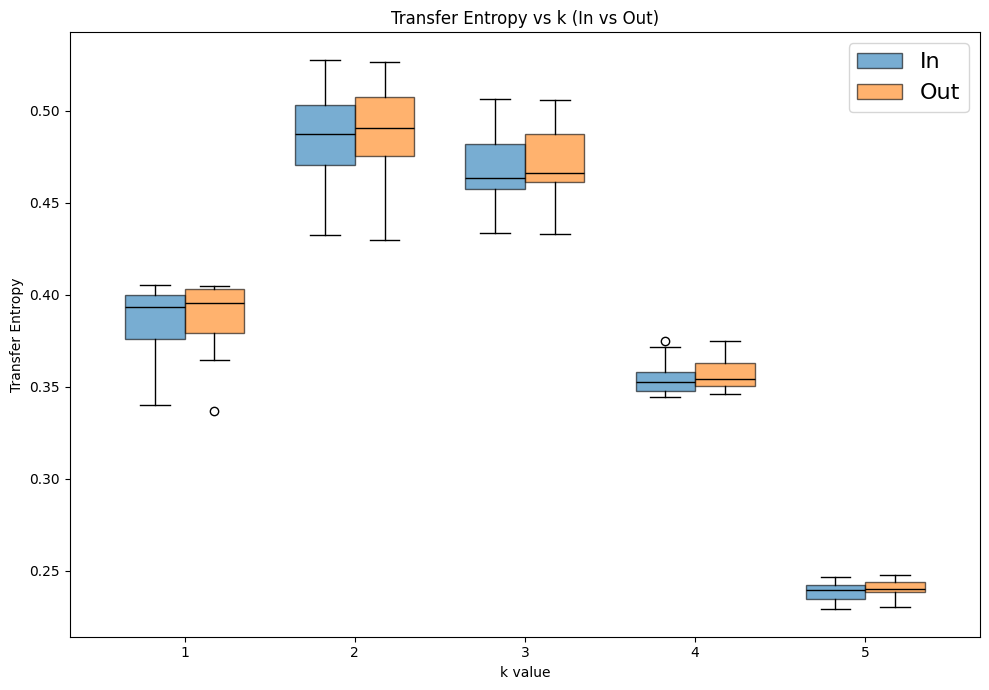

In [8]:
plot_te(te_in, te_out, k_vals)
#the following is for 6 bins

In [9]:
#ttest on each k value
from scipy.stats import ttest_rel
for k in k_vals:
    t_stat, p_val = ttest_rel(te_in[k], te_out[k])
    print(f"k={k}: t-statistic={t_stat:.4f}, p-value={p_val:.4f}")
    if p_val < 0.05:
        print(f"Significant difference at k={k} (p < 0.05)")
    else:
        print(f"No significant difference at k={k} (p >= 0.05)")

k=1: t-statistic=-1.2803, p-value=0.2412
No significant difference at k=1 (p >= 0.05)
k=2: t-statistic=-2.1252, p-value=0.0712
No significant difference at k=2 (p >= 0.05)
k=3: t-statistic=-2.4613, p-value=0.0434
Significant difference at k=3 (p < 0.05)
k=4: t-statistic=-2.1133, p-value=0.0724
No significant difference at k=4 (p >= 0.05)
k=5: t-statistic=-2.5781, p-value=0.0366
Significant difference at k=5 (p < 0.05)
